            timestamp  heart_rate  \
0 2024-01-01 00:00:00        54.6   
1 2024-01-01 00:30:00        73.2   
2 2024-01-01 01:00:00        63.8   
3 2024-01-01 01:30:00        63.7   
4 2024-01-01 02:00:00        61.8   

                                        rr_intervals sleep_stage  spo2  \
0  [1031.2805705374496, 975.9369300636871, 1022.6...        deep  96.1   
1  [961.8290467451344, 1107.887427597585, 1123.36...        deep  95.6   
2  [1009.6945038624389, 977.8591158719506, 972.61...        deep  96.4   
3  [993.8345457141529, 894.4541938484753, 973.071...        deep  96.5   
4  [1044.2006350967772, 940.9814078679569, 1008.0...         rem  96.0   

   activity_level  time_in_bed_min  total_sleep_min  
0             0.4              480              450  
1             2.5              480              450  
2             7.1              480              450  
3             3.7              480              450  
4             5.1              480              450  

Data sh

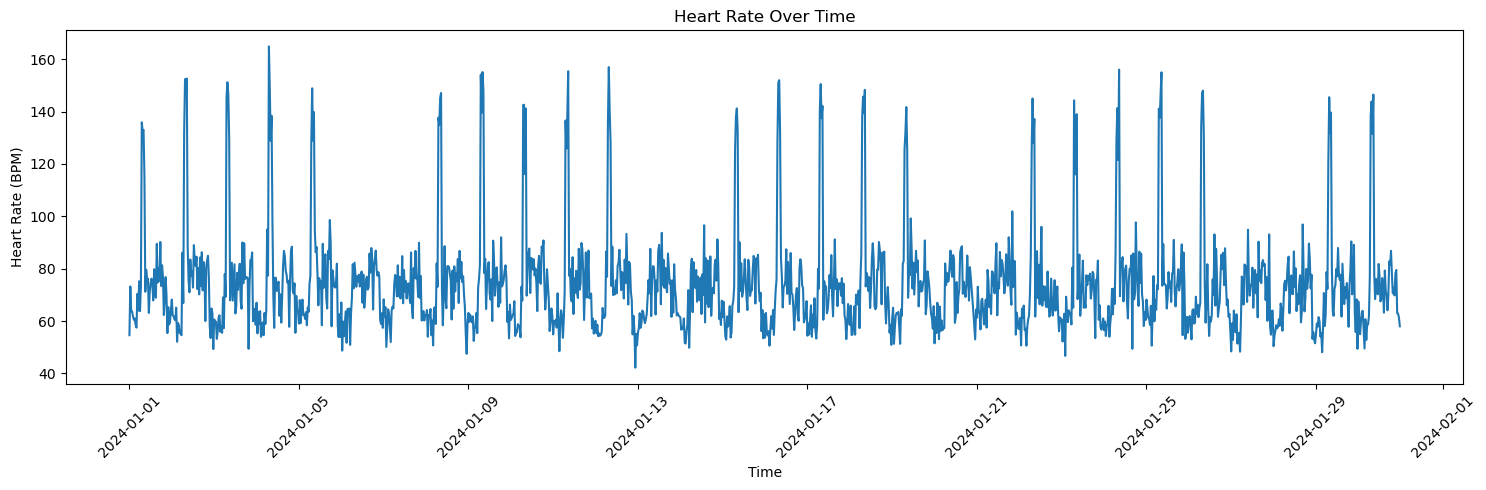

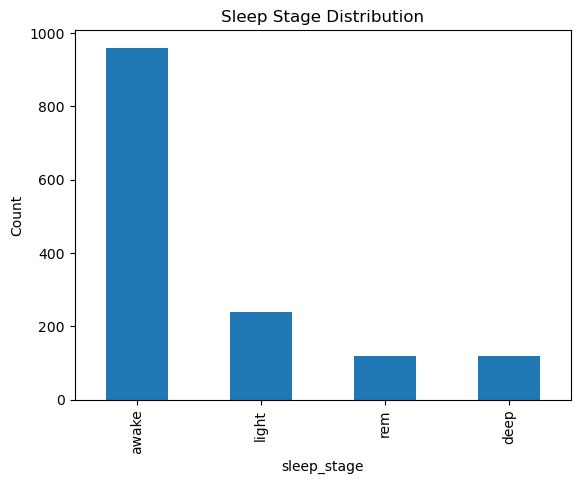

In [1]:

import pandas as pd

# Load the demo data
df = pd.read_csv('custom_demo.csv')

# Parse timestamp column
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Display basic info
print(df.head())
print(f"\nData shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

### Parse RR intervals


import ast

# Convert RR intervals from string to list
df['rr_intervals'] = df['rr_intervals'].apply(ast.literal_eval)

# Access individual RR interval lists
print(df['rr_intervals'].iloc[0])


### Basic analysis examples


# Sleep analysis
sleep_data = df[df['sleep_stage'] != 'awake']
print(f"Average sleep heart rate: {sleep_data['heart_rate'].mean():.1f} BPM")

# Activity patterns
print(f"Average daily activity: {df['activity_level'].mean():.1f}")

# Heart rate zones
print(df['heart_rate'].describe())


### Visualization examples

import matplotlib.pyplot as plt

# Plot heart rate over time
plt.figure(figsize=(15, 5))
plt.plot(df['timestamp'], df['heart_rate'])
plt.xlabel('Time')
plt.ylabel('Heart Rate (BPM)')
plt.title('Heart Rate Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sleep stages distribution
df['sleep_stage'].value_counts().plot(kind='bar')
plt.title('Sleep Stage Distribution')
plt.ylabel('Count')
plt.show()
